In [1]:
import flax
from flax import nnx
print("Flax version:", flax.__version__)

import jax
import jax.numpy as jnp
import jax.tree_util as jtu
print("Jax version:", jax.__version__)

import numpy as np
from math import prod
from typing import Callable
from tqdm import tqdm
import matplotlib.pyplot as plt

import torch
from torch.utils.data import TensorDataset, DataLoader, random_split
print(f"Pytorch version: {torch.__version__}")

import optax
print(f"Optax version: {optax.__version__}")

Flax version: 0.12.7
Jax version: 0.10.0
Pytorch version: 2.12.0
Optax version: 0.2.8


In [ ]:
class NN_Build(nnx.Module):
    def __init__(
        self,
        input_shape: tuple[int, ...],
        output_dim: int,
        layer_dims: list,
        activation: Callable = nnx.leaky_relu,
        rngs: nnx.Rngs | None = None,
        ):
        if rngs is None:
            rngs = nnx.Rngs(0)

        self.input_shape = tuple(input_shape)
        self.output_dim = output_dim
        self.layer_dims = tuple(tuple(x) if not isinstance(x, tuple) else x for x in layer_dims)
        if len(self.layer_dims) == 0:
            raise ValueError("At least one layer dimension must be specified in layer_dims.")
        self.activation = activation
        self.rngs = rngs
        self.layers = nnx.List()

        self.check_layer_dims(self.input_shape, self.output_dim, self.layer_dims)

        if len(self.layer_dims) == 1:
            self._add_layer(self.layer_dims[0], None, self.layers)#, final_layer=True)
        else:
            self._add_layer(self.layer_dims[0], None, self.layers)#, final_layer=False)
            size_prev = self.layer_dims[0]
            for size_new in self.layer_dims[1:-1]:
                self._add_layer(size_new, size_prev, self.layers)#, final_layer=False)
                size_prev = size_new
            self._add_layer(self.layer_dims[-1], size_prev, self.layers)#, final_layer=True)
            size_prev = self.layer_dims[-1]

    def check_layer_dims(
        self,
        input_shape: tuple[int, ...],
        output_dim: int,
        layer_dims: list,
        ):
        data_shape = tuple(input_shape)

        for layer_dim in layer_dims:
            if len(layer_dim) not in (2, 3):
                raise ValueError(
                    f"Each layer dimension must be a tuple of length 2 (linear) or 3 "
                    f"(convolutional). Got {layer_dim}."
                )

            if len(layer_dim) == 2:
                current_flat_dim = prod(data_shape)
                if current_flat_dim != layer_dim[0]:
                    raise ValueError(
                        f"Expected input shape {data_shape} to be compatible with linear "
                        f"layer input dimension {layer_dim[0]}."
                    )
                data_shape = (layer_dim[1],)

            elif len(layer_dim) == 3:
                if len(data_shape) != 3:
                    raise ValueError(
                        f"Cannot add a convolutional layer after a linear layer, got "
                        f"layer dimensions {layer_dim} after input shape {data_shape}."
                    )

                if data_shape[2] != layer_dim[0]:
                    raise ValueError(
                        f"Expected input shape {data_shape} to be compatible with "
                        f"convolutional layer input channels {layer_dim[0]}."
                    )

                new_h = data_shape[0] - layer_dim[2] + 1
                new_w = data_shape[1] - layer_dim[2] + 1
                if new_h <= 0 or new_w <= 0:
                    raise ValueError(
                        f"Convolution with kernel size {layer_dim[2]} is too large for "
                        f"spatial shape {data_shape[:2]}."
                    )

                data_shape = (new_h, new_w, layer_dim[1])

        if data_shape != (output_dim,):
            raise ValueError(
                f"Final layer shape {data_shape} does not match output dimension {output_dim}."
            )

    class Flatten(nnx.Module):
        def __call__(self, x):
            return x.reshape(x.shape[:-3] + (-1,))

    def _add_layer(
        self,
        layer_dim: tuple,
        prev_layer_dim: tuple | None,
        layers: nnx.List,
        # final_layer: bool = False,
        ):
        # class Flatten(nnx.Module):
        #     def __call__(self, x):
        #         return x.reshape((x.shape[0], -1))
        if prev_layer_dim is None:
            if len(layer_dim) == 2:
                if len(self.input_shape) == 1:
                    if self.input_shape[0] != layer_dim[0]:
                        raise ValueError(
                            f"Expected input shape {self.input_shape} to match linear "
                            f"input dimension {layer_dim[0]}."
                        )
                    layers.append(nnx.Linear(layer_dim[0], layer_dim[1], rngs=self.rngs))
                elif len(self.input_shape) == 3:
                    if prod(self.input_shape) != layer_dim[0]:
                        raise ValueError(
                            f"Expected flattened input size {prod(self.input_shape)} to "
                            f"match linear input dimension {layer_dim[0]}."
                        )
                    layers.append(AverageBlock(L_in=self.input_shape[0]))
                    layers.append(nnx.Linear(layer_dim[0], layer_dim[1], rngs=self.rngs))
                else:
                    raise ValueError(f"Unsupported input shape {self.input_shape}.")

            elif len(layer_dim) == 3:
                if len(self.input_shape) != 3:
                    raise ValueError(
                        f"Cannot add a convolutional layer after a linear layer, got "
                        f"layer dimensions {layer_dim} after input shape {self.input_shape}."
                    )
                if self.input_shape[2] != layer_dim[0]:
                    raise ValueError(
                        f"Expected input channels {self.input_shape[2]} to match "
                        f"convolutional input channels {layer_dim[0]}."
                    )
                layers.append(
                    nnx.Conv(
                        layer_dim[0],
                        layer_dim[1],
                        kernel_size=(layer_dim[2], layer_dim[2]),
                        padding="VALID",
                        rngs=self.rngs,
                    )
                )   

        else:
            if len(layer_dim) == 2 and len(prev_layer_dim) == 2:
                if prev_layer_dim[1] != layer_dim[0]:
                    raise ValueError(
                        f"Linear layer input dimension {layer_dim[0]} does not match "
                        f"previous layer output dimension {prev_layer_dim[1]}."
                    )
                layers.append(nnx.Linear(layer_dim[0], layer_dim[1], rngs=self.rngs))

            elif len(layer_dim) == 3 and len(prev_layer_dim) == 3:
                if prev_layer_dim[1] != layer_dim[0]:
                    raise ValueError(
                        f"Convolutional layer input channels {layer_dim[0]} do not match "
                        f"previous layer output channels {prev_layer_dim[1]}."
                    )
                layers.append(
                    nnx.Conv(
                        layer_dim[0],
                        layer_dim[1],
                        kernel_size=(layer_dim[2], layer_dim[2]),
                        padding="VALID",
                        rngs=self.rngs,
                    )
                )

            elif len(layer_dim) == 2 and len(prev_layer_dim) == 3:
                layers.append(self.Flatten())
                layers.append(nnx.Linear(layer_dim[0], layer_dim[1], rngs=self.rngs))

            elif len(layer_dim) == 3 and len(prev_layer_dim) == 2:
                raise ValueError(
                    f"Cannot add a convolutional layer after a linear layer, got "
                    f"layer dimensions {layer_dim} after {prev_layer_dim}."
                )

        # if not final_layer:
        #     layers.append(self.activation)

    def __call__(self, x):
        if len(self.layers) > 1:
            for layer in self.layers[:-1]:
                x = layer(x)
                x = self.activation(x)
            x = self.layers[-1](x)
        elif len(self.layers) == 1:
            for layer in self.layers:
                x = layer(x)
        return x

In [5]:
# with np.load('../sbi_lens_sims/mpi_job_4483820_combined.npz') as data:
with np.load('../sbi_lens_sims/combined_overall.npz') as data:
    x = data['y']
    # Flax Conv layers expects data shape in (N, H, W, C) format
    y = data['theta']
    # Remove any NaN data points
    nan_mask = jnp.isnan(x).reshape(x.shape[0], -1).any(axis=1)
    clean_indices = jnp.where(~nan_mask)[0]
    x = x[clean_indices]
    y = y[clean_indices]
    N_data = x.shape[0]
    print("x", x.shape, "\ny", y.shape)


def mse_loss(model, x, y):
    preds = model(x)
    if preds.shape != y.shape:
        raise ValueError(f"Output shpae of the model {preds.shape} does not match the shape of the labels {y.shape}")
    return jnp.mean((preds-y) ** 2)



x (66295, 60, 60, 5) 
y (66295, 6)


In [9]:
BATCH_SIZE = 512
LEARNING_RATE = 5e-6
STEPS = 1500
PRINT_EVERY = 100
TRAIN_TEST_SPLIT = 0.8
rngs = nnx.Rngs(0)

input_shape = (60,60,5)
output_dim = 6
layer_dims = ((5,3,11), (3,1,11), (1,1,11), (30*30, 100), (100, output_dim))
CNN = NN_Build(input_shape, output_dim, layer_dims)
# print(CNN)

x_tensor = torch.tensor(np.array(x), dtype=torch.float32)
y_tensor = torch.tensor(np.array(y), dtype=torch.float32)
dataset = TensorDataset(x_tensor, y_tensor)
train_size = int(TRAIN_TEST_SPLIT * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)


optimizer = nnx.Optimizer(
  CNN, optax.adamw(LEARNING_RATE), wrt=nnx.Param
)
metrics = nnx.MultiMetric(
  loss=nnx.metrics.Average('loss'),
)
# nnx.display(optimizer)

@nnx.jit
def train_step(model, optimizer: nnx.Optimizer, metrics: nnx.MultiMetric, x_batch, y_batch, rngs: nnx.Rngs):
    """Train for a single step."""
    loss_value, grads = nnx.value_and_grad(mse_loss)(model, x_batch, y_batch)
    metrics.update(loss=loss_value)  # In-place updates.
    optimizer.update(model, grads)  # In-place updates.
    return loss_value

@nnx.jit
def eval_step(model, metrics, x, y):
    """Calculate loss on test data without updating parameters."""
    loss_value = mse_loss(model, x, y)
    metrics.update(loss=loss_value)
    return loss_value

 # Loop over our training dataset as many times as we need.
def infinite_trainloader():
    while True:
        yield from train_loader
    
train_losses = []
test_losses = []
test_steps = []

for step, (x_batch, y_batch) in tqdm(zip(range(STEPS), infinite_trainloader())):
    train_loss = train_step(CNN, optimizer, metrics, x_batch.numpy(), y_batch.numpy(), rngs)

    # train_loss = metrics.compute()['loss']
    train_losses.append(train_loss)
    
    # --- EVALUATION PHASE ---
    if step % PRINT_EVERY == 0:
        # metrics.reset() # Clear training metrics to track test metrics
        for batch_x, batch_y in test_loader:
            test_loss = eval_step(CNN, metrics, batch_x.numpy(), batch_y.numpy())
        
        # test_loss = metrics.compute()['loss']
        test_losses.append(test_loss)
        test_steps.append(step)
        print(f"Step {step:3d} ({(step*BATCH_SIZE)/N_data:.1f} epoch)| Train Loss: {train_loss:.6f} | Test Loss: {test_loss:.6f}")
print("Training completed.")

        
# for epoch in tqdm(range(EPOCHS)):
#     # --- TRAINING PHASE ---
#     metrics.reset() # Clear metrics for the new epoch
#     for x_batch, y_batch in train_loader:
#         train_step(CNN, optimizer, metrics, x_batch.numpy(), y_batch.numpy(), rngs)
    
#     train_loss = metrics.compute()['loss']
    
#     # --- EVALUATION PHASE ---
#     if epoch % PRINT_EVERY == 0:
#         metrics.reset() # Clear training metrics to track test metrics
#         for batch_x, batch_y in test_loader:
#             eval_step(CNN, metrics, batch_x.numpy(), batch_y.numpy())
        
#         test_loss = metrics.compute()['loss']
#         print(f"Epoch {epoch:3d} | Train Loss: {train_loss:.6f} | Test Loss: {test_loss:.6f}")
    # else:
        # Just print training progress on other epochs
        # print(f"Epoch {epoch:3d} | Train Loss: {train_loss:.6f}")

12it [00:03,  5.28it/s]

Step   0 (0.0 epoch)| Train Loss: 0.605075 | Test Loss: 0.614684


101it [00:35,  4.10s/it]

Step 100 (0.8 epoch)| Train Loss: 0.604105 | Test Loss: 0.606798


221it [01:10,  2.29it/s]

...

Step 1300 (10.0 epoch)| Train Loss: 0.047110 | Test Loss: 0.048387


1418it [08:33,  1.87it/s]

Step 1400 (10.8 epoch)| Train Loss: 0.045814 | Test Loss: 0.048292


1500it [08:54,  2.80it/s]

Training completed.


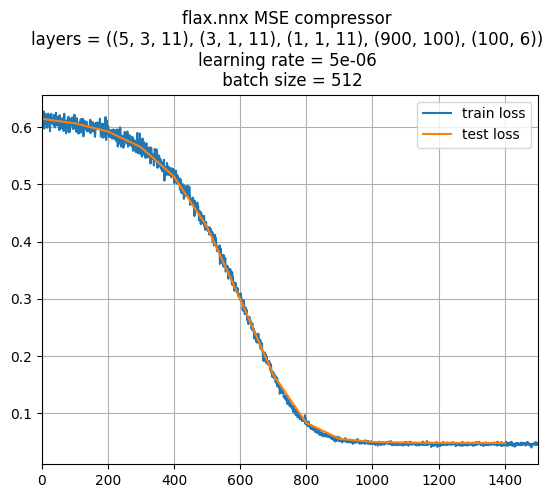

(66295, 6) (66295, 6)


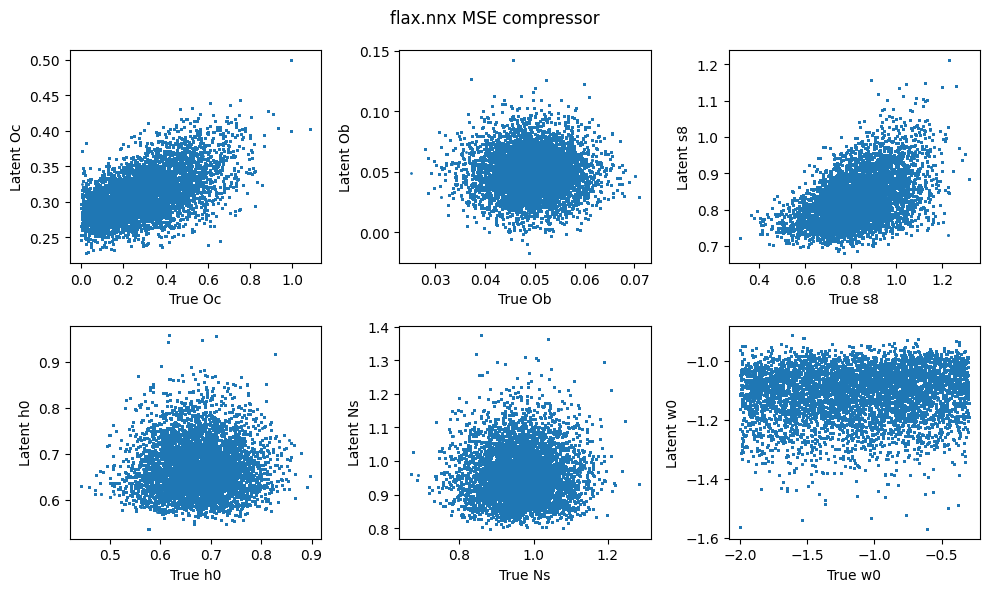

In [10]:
# Training loss time series
fig, ax = plt.subplots()
ax.plot(range(STEPS), train_losses, label='train loss')
ax.plot(test_steps, test_losses, label='test loss')
ax.set_xlim(0,STEPS)
plt.grid()
plt.legend()
plt.title(f"flax.nnx MSE compressor \nlayers = {layer_dims} \nlearning rate = {LEARNING_RATE} \n batch size = {BATCH_SIZE}")
plt.savefig(f"nnx_MSE_loss_{STEPS}_steps.pdf")
plt.show()


# Truth vs Latent diagnostic scatter
gt = ground_truth = y
cp = compressed_data = CNN(x)
print(compressed_data.shape, y.shape)

params = ['Oc','Ob','s8','h0','Ns','w0']
num_params = ground_truth.shape[1]

fig, axes = plt.subplots(2, 3, figsize=(10,6))
axes = axes.flatten()
for i in range(num_params):
    ax = axes[i]
    ax.scatter(gt[:,i], cp[:,i], s=1)
    ax.set_xlabel(f'True {params[i]}')
    ax.set_ylabel(f'Latent {params[i]}')

plt.suptitle("flax.nnx MSE compressor")
plt.tight_layout()
# plt.savefig(f"nnx_MSE_scatter_{STEPS}_steps.pdf")
plt.show()

(66295, 6) (66295, 6)


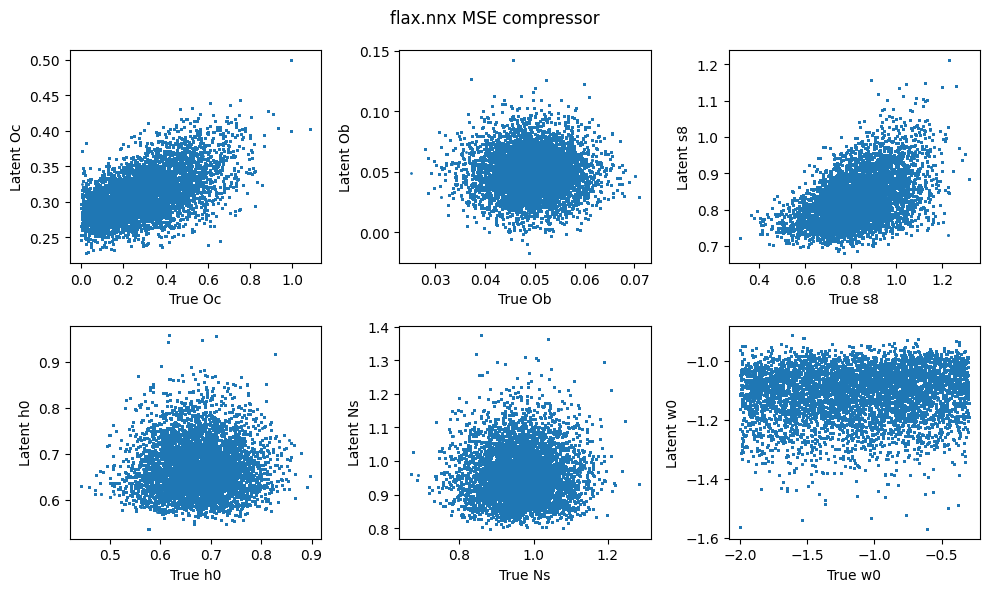

In [11]:
import seaborn as sns
import pandas as pd

gt = ground_truth = y
cp = compressed_data = CNN(x)
print(compressed_data.shape, y.shape)

params = ['Oc','Ob','s8','h0','Ns','w0']
num_params = ground_truth.shape[1]

fig, axes = plt.subplots(2, 3, figsize=(10,6))
axes = axes.flatten()
for i in range(num_params):
    ax = axes[i]
    ax.scatter(gt[:,i], cp[:,i], s=1)
    ax.set_xlabel(f'True {params[i]}')
    ax.set_ylabel(f'Latent {params[i]}')

plt.suptitle("flax.nnx MSE compressor")
plt.tight_layout()
# plt.savefig(f"nnx_MSE_scatter_{STEPS}_steps.pdf")
plt.show()

In [22]:
print(cp)
print(CNN)

[[ 0.24226631  0.03654247  0.78910065  0.6595341   0.8890585  -1.0698688 ]
 [ 0.34858334  0.07048474  0.9066953   0.6921973   1.041403   -1.1880097 ]
 [ 0.3261088   0.03817313  0.8568979   0.6789722   0.98646104 -1.1532868 ]
 ...
 [ 0.275392    0.03180655  0.8020204   0.6237841   0.9091066  -1.0821763 ]
 [ 0.33385095  0.05045508  0.8603414   0.6681408   1.0024396  -1.1651293 ]
 [ 0.27870974  0.05398385  0.78823185  0.6804549   0.9238461  -1.1123123 ]]
NN_Build( # Param: 93,010 (372.0 KB), RngState: 2 (12 B), Total: 93,012 (372.1 KB)
  activation=<jax._src.custom_derivatives.custom_jvp object at 0x11347c210>,
  input_shape=(60, 60, 5),
  layer_dims=((5, 3, 11), (3, 1, 11), (1, 1, 11), (900, 100), (100, 6)),
  layers=List([
    Conv( # Param: 1,818 (7.3 KB)
      bias=Param( # 3 (12 B)
        value=Array(shape=(3,), dtype=dtype('float32'))
      ),
      conv_general_dilated=<function conv_general_dilated at 0x112ef05e0>,
      dtype=None,
      feature_group_count=1,
      in_features=